In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

In [3]:
# Create a realistic dataset
np.random.seed(42)

n = 1000

age = np.random.randint(22, 60, n)
annual_income = np.random.randint(300000, 2500000, n)
investments = np.random.randint(10000, 500000, n)
deductions = np.random.randint(5000, 300000, n)

tax_paid = (
    annual_income * 0.15
    - investments * 0.08
    - deductions * 0.05
    + np.random.randint(-10000, 10000, n)
)

df = pd.DataFrame({
    "Age": age,
    "Annual_Income": annual_income,
    "Investments": investments,
    "Deductions": deductions,
    "Tax_Paid": tax_paid
})

df.head()

,Age,Annual_Income,Investments,Deductions,Tax_Paid
0,50,2268797,39956,231416,321180.27
1,36,1408252,248340,283859,175505.65
2,29,2090380,114797,160378,301888.34
3,42,1963261,397061,155158,264710.37
4,40,1966471,398447,146130,265177.39


In [4]:
# Save dataset
df.to_csv("../data/income_tax_data.csv", index=False)

print("Dataset saved successfully!")
print(df.shape)

Dataset saved successfully!
(1000, 5)


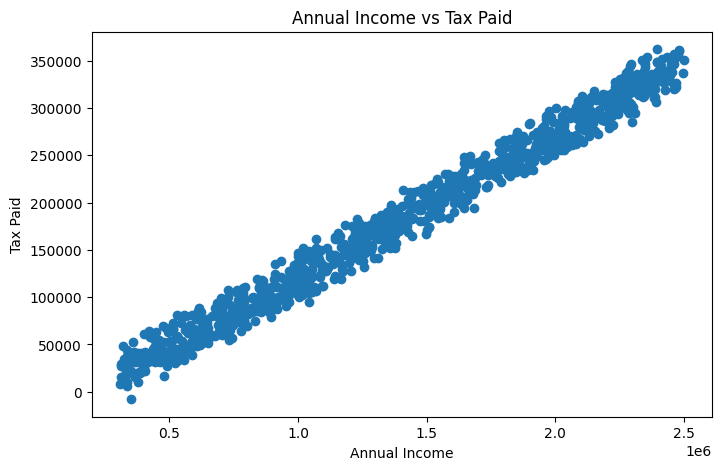

In [5]:
# Data Visualization

plt.figure(figsize=(8,5))
plt.scatter(df["Annual_Income"], df["Tax_Paid"])
plt.title("Annual Income vs Tax Paid")
plt.xlabel("Annual Income")
plt.ylabel("Tax Paid")
plt.show()

In [6]:
# Select Features and Target

X = df[["Age", "Annual_Income", "Investments", "Deductions"]]
y = df["Tax_Paid"]

In [7]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
# Train Random Forest Model

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [9]:
# Evaluate Model

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9946922259530434
MAE: 5644.702986999997


In [10]:
# Test Prediction

sample = [[30, 600000, 120000, 40000]]

prediction = model.predict(sample)

print("Predicted Tax:", round(prediction[0], 2))

Predicted Tax: 76022.23


c:\Users\skkha\OneDrive\Desktop\Income-Tax-Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [11]:
joblib.dump(model, "../model/income_tax_model.pkl")
print("Model saved successfully!")

Model saved successfully!
